# E-Commerce Sales & Profitability Analysis

---

## Objective
Analyse transactional sales data to identify where the business is making profit and where it is losing money — across product categories, regions, customer segments, and discount behaviour.



## Step 1 — Import Libraries

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Chart styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11

print('All libraries imported successfully')

All libraries imported successfully


## Step 2 — Load Data

In [28]:
# Load the CSV exported from MySQL
df = pd.read_csv('../e-commerce data/demo/semi_cleaned_123.csv')

print(f'Rows : {df.shape[0]:,}')
print(f'Columns : {df.shape[1]}')
print(f'\nColumn names:')
print(df.columns.tolist())

Rows : 9,994
Columns : 21

Column names:
['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode', 'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State', 'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category', 'Product_Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [29]:
# Preview first 5 rows
df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,...,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,08-11-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,2,CA-2016-152156,08-11-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,3,CA-2016-138688,12-06-2016,16-06-2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87
3,4,US-2015-108966,11-10-2015,18-10-2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03
4,5,US-2015-108966,11-10-2015,18-10-2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52


In [30]:
# Check data types
df.dtypes

Row_ID             int64
Order_ID          object
Order_Date        object
Ship_Date         object
Ship_Mode         object
Customer_ID       object
Customer_Name     object
Segment           object
Country           object
City              object
State             object
Postal_Code        int64
Region            object
Product_ID        object
Category          object
Sub_Category      object
Product_Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

## Step 3 — Data Cleaning

In [31]:
# 3.1 — Check for null values
print('=== NULL VALUES ===')
print(df.isnull().sum())
print(f'\nTotal nulls: {df.isnull().sum().sum()}')

=== NULL VALUES ===
Row_ID           0
Order_ID         0
Order_Date       0
Ship_Date        0
Ship_Mode        0
Customer_ID      0
Customer_Name    0
Segment          0
Country          0
City             0
State            0
Postal_Code      0
Region           0
Product_ID       0
Category         0
Sub_Category     0
Product_Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Total nulls: 0


In [32]:
# 3.2 — Check for duplicate rows
duplicates = df.duplicated().sum()
print(f'Duplicate rows: {duplicates}')

# Drop duplicates if any exist
if duplicates > 0:
    df = df.drop_duplicates()
    print(f'Duplicates removed. New shape: {df.shape}')
else:
    print('No duplicates found — data is clean')

Duplicate rows: 0
No duplicates found — data is clean


In [33]:
# 3.3 — Convert date columns from string to datetime
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%d-%m-%Y', errors='coerce')
df['Ship_Date']  = pd.to_datetime(df['Ship_Date'],  format='%d-%m-%Y', errors='coerce')

# Check how many converted successfully
print(f'Order_Date nulls after conversion : {df["Order_Date"].isnull().sum()}')
print(f'Ship_Date nulls after conversion  : {df["Ship_Date"].isnull().sum()}')
print(f'\nDate range: {df["Order_Date"].min().date()} to {df["Order_Date"].max().date()}')

Order_Date nulls after conversion : 0
Ship_Date nulls after conversion  : 0

Date range: 2014-01-03 to 2017-12-30


In [34]:
# 3.4 — Fix text columns: strip whitespace, consistent capitalisation
text_cols = ['Ship_Mode', 'Segment', 'Country', 'City',
             'State', 'Region', 'Category', 'Sub_Category']

for col in text_cols:
    df[col] = df[col].str.strip().str.title()

print('Text columns cleaned')
print('\nUnique Categories :', df['Category'].unique())
print('Unique Regions    :', df['Region'].unique())
print('Unique Segments   :', df['Segment'].unique())

Text columns cleaned

Unique Categories : ['Furniture' 'Office Supplies' 'Technology']
Unique Regions    : ['South' 'West' 'Central' 'East']
Unique Segments   : ['Consumer' 'Corporate' 'Home Office']


In [35]:
# Check distribution of Sales and Profit before outlier removal
df[['Sales','Profit']].describe()

,Sales,Profit
count,9994.000000,9994.000000
mean,229.858022,28.656973
std,623.245131,234.260203
min,0.440000,-6599.980000
25%,17.280000,1.730000
50%,54.490000,8.665000
75%,209.940000,29.360000
max,22638.480000,8399.980000


In [36]:
# 3.5 — Remove statistical outliers using IQR method
# We apply this to Sales and Profit columns only

def remove_outliers_iqr(dataframe, column):
    Q1  = dataframe[column].quantile(0.25)
    Q3  = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3 * IQR  # using 3x IQR to keep business-valid extreme values
    upper = Q3 + 3 * IQR
    before = len(dataframe)
    dataframe = dataframe[(dataframe[column] >= lower) & (dataframe[column] <= upper)]
    after = len(dataframe)
    print(f'{column}: removed {before - after} outliers (kept {after:,} rows)')
    return dataframe

df = remove_outliers_iqr(df, 'Sales')
df = remove_outliers_iqr(df, 'Profit')

print(f'\nFinal shape after outlier removal: {df.shape}')

Sales: removed 668 outliers (kept 9,326 rows)
Profit: removed 874 outliers (kept 8,452 rows)

Final shape after outlier removal: (8452, 21)


## Step 4 — Feature Engineering

Creating new columns from existing data that will be useful for analysis.

In [37]:
# 4.1 — Extract date parts for time-based analysis
df['Order_Year']    = df['Order_Date'].dt.year
df['Order_Month']   = df['Order_Date'].dt.month
df['Order_Quarter'] = df['Order_Date'].dt.quarter
df['Month_Name']    = df['Order_Date'].dt.strftime('%b')  # Jan, Feb etc

# 4.2 — Profit margin percentage
df['Profit_Margin_Pct'] = round((df['Profit'] / df['Sales']) * 100, 2)

# 4.3 — Discount bands for grouping
df['Discount_Band'] = pd.cut(
    df['Discount'],
    bins   = [-0.01, 0, 0.10, 0.20, 0.40, 1.0],
    labels = ['No Discount', '1-10%', '11-20%', '21-40%', 'Above 40%']
)

print('New columns added:')
new_cols = ['Order_Year','Order_Month','Order_Quarter','Month_Name','Profit_Margin_Pct','Discount_Band']
print(df[new_cols].head(3))

New columns added:
   Order_Year  Order_Month  Order_Quarter Month_Name  Profit_Margin_Pct  \
0        2016           11              4        Nov              16.00   
2        2016            6              2        Jun              46.99   
4        2015           10              4        Oct              11.27   

  Discount_Band  
0   No Discount  
2   No Discount  
4        11-20%  


In [38]:
# Final data snapshot before analysis
print('=== FINAL DATASET SUMMARY ===')
print(f'Total Orders          : {len(df):,}')
print(f'Unique Customers      : {df["Customer_ID"].nunique():,}')
print(f'Unique Products       : {df["Product_ID"].nunique():,}')
print(f'Total Revenue         : ${df["Sales"].sum():,.0f}')
print(f'Total Profit          : ${df["Profit"].sum():,.0f}')
print(f'Overall Profit Margin : {round(df["Profit"].sum()/df["Sales"].sum()*100,1)}%')
print(f'Avg Discount Given    : {round(df["Discount"].mean()*100,1)}%')
print(f'Date Range            : {df["Order_Date"].min().date()} to {df["Order_Date"].max().date()}')

=== FINAL DATASET SUMMARY ===
Total Orders          : 8,452
Unique Customers      : 789
Unique Products       : 1,735
Total Revenue         : $769,427
Total Profit          : $105,634
Overall Profit Margin : 13.7%
Avg Discount Given    : 15.1%
Date Range            : 2014-01-03 to 2017-12-30


## Step 5 — Exploratory Data Analysis & Charts

### Chart 1 — Total Profit by Category

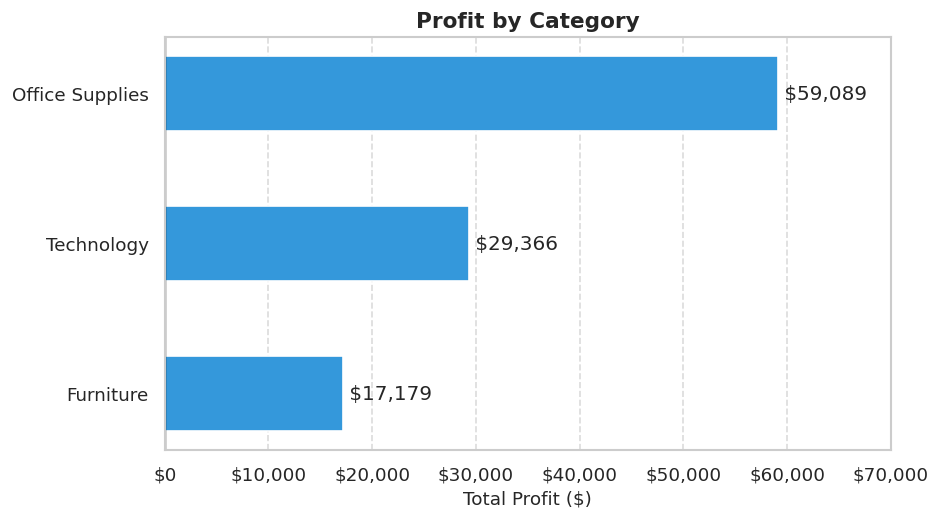

Category Performance — Full Breakdown
                 Orders  Order_%  Total_Sales  Revenue_%  Total_Profit  Profit_%  Margin_%  Avg_Order_Value  Avg_Profit_Per_Order
Category                                                                                                                         
Office Supplies    5509     65.2    300146.97       39.0      59088.74      55.9     19.69            54.48                 10.73
Technology         1364     16.1    212088.85       27.6      29366.20      27.8     13.85           155.49                 21.53
Furniture          1579     18.7    257191.49       33.4      17179.36      16.3      6.68           162.88                 10.88


In [39]:
# --- Category Profit Visualization ---
cat_profit = df.groupby('Category')['Profit'].sum().sort_values()

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ['#e74c3c' if x < 0 else '#3498db' for x in cat_profit]

ax.barh(cat_profit.index, cat_profit.values, color=colors, edgecolor='white', height=0.5)

ax.set_title('Profit by Category')
ax.set_xlabel('Total Profit ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.axvline(0, color='black', linewidth=0.8)

for i, v in enumerate(cat_profit.values):
    ax.text(v, i, f' ${v:,.0f}', va='center',
            ha='left' if v > 0 else 'right')
    
ax.xaxis.grid(True, linestyle='--', alpha=0.7)
ax.yaxis.grid(False)
ax.set_xlim(0,70000)
plt.tight_layout()
plt.show()


# Category full breakdown — Sales, Profit, Margin, Orders together
cat_summary = df.groupby('Category').agg(
    Orders               = ('Sales',  'count'),
    Total_Sales          = ('Sales',  'sum'),
    Total_Profit         = ('Profit', 'sum'),
    Avg_Order_Value      = ('Sales',  'mean'),
    Avg_Profit_Per_Order = ('Profit', 'mean')
).round(2)

cat_summary['Margin_%']  = (cat_summary['Total_Profit'] / cat_summary['Total_Sales'] * 100).round(2)
cat_summary['Revenue_%'] = (cat_summary['Total_Sales']  / cat_summary['Total_Sales'].sum() * 100).round(1)
cat_summary['Profit_%']  = (cat_summary['Total_Profit'] / cat_summary['Total_Profit'].sum() * 100).round(1)
cat_summary['Order_%']   = (cat_summary['Orders']       / cat_summary['Orders'].sum() * 100).round(1)

cat_summary = cat_summary[[
    'Orders', 'Order_%',
    'Total_Sales', 'Revenue_%',
    'Total_Profit', 'Profit_%',
    'Margin_%',
    'Avg_Order_Value', 'Avg_Profit_Per_Order'
]].sort_values('Total_Profit', ascending=False)

print('Category Performance — Full Breakdown')
print(cat_summary.to_string())

**Insight:**  
Office Supplies leads with \\\$59,089 profit at 19.69% margin — nearly
3x Furniture's 6.68%. Technology has fewer orders but earns the
highest avg profit per transaction at \\\$21.53. Furniture is the concern
— \\\$257,191 in revenue but margin too thin to show for it. Chart 2
identifies which sub-categories are responsible.

### Chart 2 — Profit by Sub-Category (Finding the Losers)

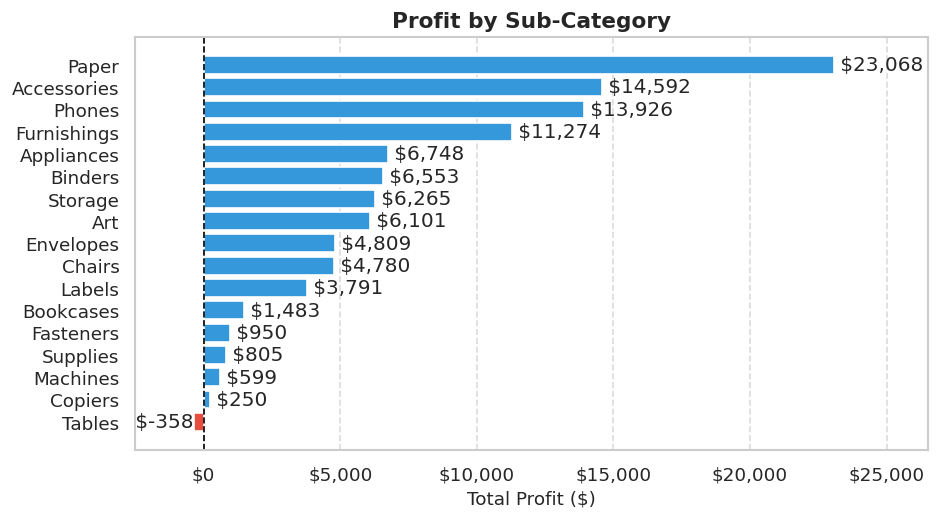

In [40]:
sub_profit = df.groupby('Sub_Category')['Profit'].sum().sort_values()

fig, ax = plt.subplots(figsize=(8, 4.5))

colors = ['#e74c3c' if x < 0 else '#3498db' for x in sub_profit]
ax.barh(sub_profit.index, sub_profit.values, color=colors)

for i, v in enumerate(sub_profit.values):
    ax.text(v, i, f' ${v:,.0f}',
            va='center',
            ha='left' if v > 0 else 'right')

ax.axvline(0, color='black', linestyle='--', linewidth=1)

ax.set_title('Profit by Sub-Category')
ax.set_xlabel('Total Profit ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

ax.xaxis.grid(True, linestyle='--', alpha=0.7)
ax.yaxis.grid(False)
ax.set_xlim(-2500, 26500)
plt.tight_layout()
plt.show()

**Insight:**

16 of 17 sub-categories are profitable. Tables is the only exception
at \\\$-358, dragging Furniture's category margin down despite Furnishings
(\\\$11,274) and Chairs (\\\$4,780) performing well. Business should check
whether Tables is being over-discounted and reprice if necessary.

### Chart 3 — Total Sales and Profit by Region

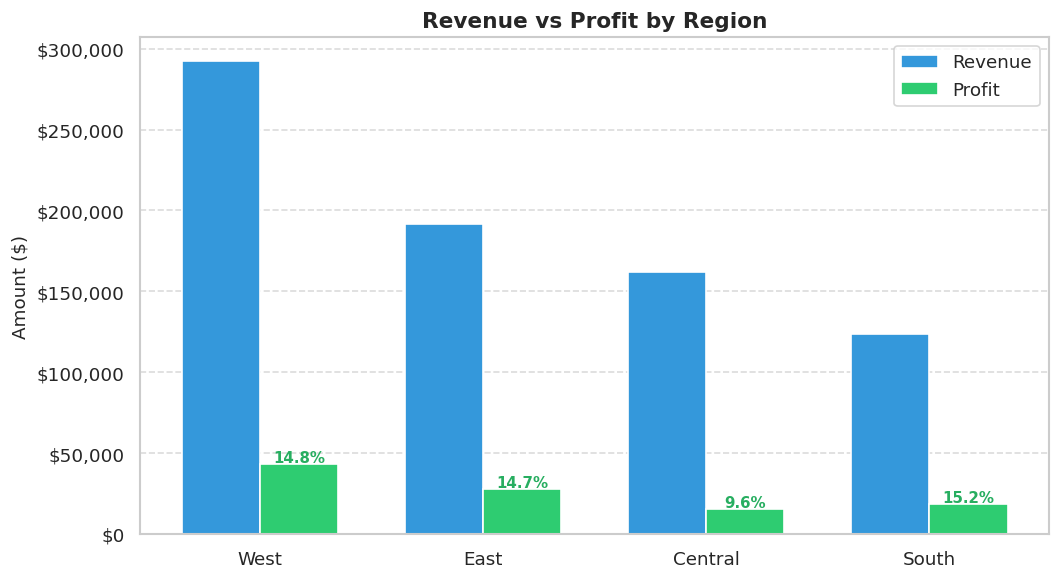

 Region  Total_Sales  Total_Profit  Profit_Margin
   West    292419.74      43187.33           14.8
   East    191521.54      28084.00           14.7
Central    162097.05      15587.85            9.6
  South    123388.98      18775.12           15.2


In [41]:
region_data = df.groupby('Region').agg(
    Total_Sales  = ('Sales', 'sum'),
    Total_Profit = ('Profit', 'sum')
).sort_values('Total_Sales', ascending=False).reset_index()

region_data['Profit_Margin'] = (region_data['Total_Profit'] / region_data['Total_Sales'] * 100).round(1)

x     = range(len(region_data))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar([i - width/2 for i in x], region_data['Total_Sales'],
               width=width, label='Revenue', color='#3498db', edgecolor='white')
bars2 = ax.bar([i + width/2 for i in x], region_data['Total_Profit'],
               width=width, label='Profit',  color='#2ecc71', edgecolor='white')

# Add margin % annotation above each profit bar
for i, (bar, margin) in enumerate(zip(bars2, region_data['Profit_Margin'])):
    ax.text(i + width/2, bar.get_height() + 1000,
            f'{margin}%', ha='center', fontsize=9,
            fontweight='bold', color='#27ae60')
    
ax.set_xticks(list(x))
ax.set_xticklabels(region_data['Region'])
ax.set_ylabel('Amount ($)')
ax.set_title('Revenue vs Profit by Region')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
ax.xaxis.grid(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(region_data.to_string(index=False))


**Insight:**

West leads on revenue and profit at 14.77% margin. South earns the
highest margin (15.22%) on the lowest revenue — disciplined pricing.
Central is the problem — 9.62% margin vs business average 13.73%,
representing 6,666 in recoverable profit. No region runs at a loss
but Central's discount behaviour needs auditing first.

### Chart 4 — Impact of Discount on Profit (The Key Finding)

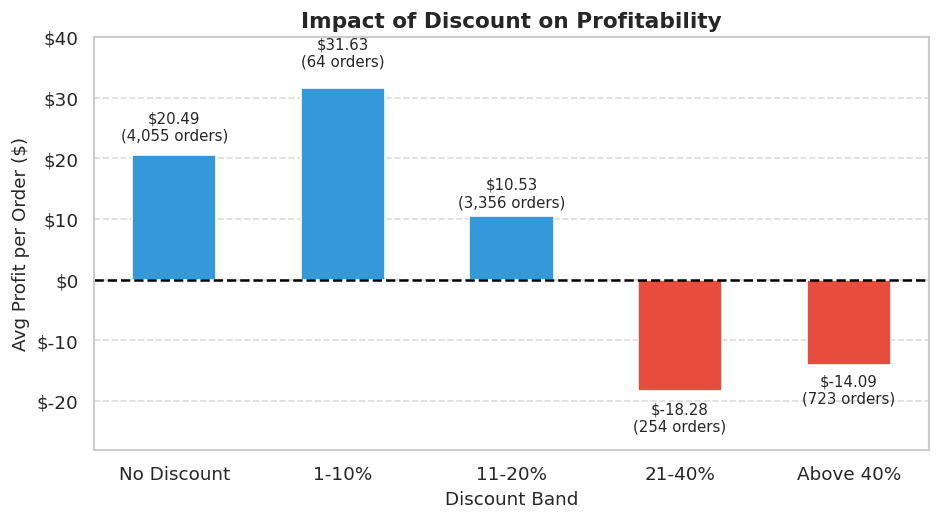

In [42]:
disc_data = df.groupby('Discount_Band', observed=True).agg(
    Avg_Profit=('Profit', 'mean'),
    Total_Orders=('Sales', 'count')).reset_index()

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ['#e74c3c' if x < 0 else '#3498db' for x in disc_data['Avg_Profit']]
ax.bar(disc_data['Discount_Band'].astype(str),disc_data['Avg_Profit'],
       color=colors, edgecolor='white', width=0.5)

for i, (val, orders) in enumerate(zip(disc_data['Avg_Profit'], disc_data['Total_Orders'])):
    offset = abs(val) * 0.1 if val != 0 else 0.1
    ax.text(i, val + (offset if val >= 0 else -offset),
            f'${val:.2f}\n({orders:,} orders)',
            ha='center',va='bottom' if val >= 0 else 'top',fontsize=9)

ax.axhline(0, color='black', linestyle='--')
ax.set_title('Impact of Discount on Profitability')
ax.set_xlabel('Discount Band')
ax.set_ylabel('Avg Profit per Order ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_ylim(-28, 40)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.xaxis.grid(False)

plt.tight_layout()
plt.show()

**Insight:**  
This is the clearest finding in the entire analysis. Profit is positive up to 20% discount. No discount averages \\\$20.49,
1-10% does best at \\\$31.63. Cross 20% and profit flips negative —
977 orders above this threshold collectively destroyed \\\$14,830 in
profit on \\\$68,906 revenue. One in 9 orders is losing money.
Cap discounts at 20% company-wide and this stops immediately.

### Chart 5 — Scatter: Do Higher Sales Mean Higher Profit?

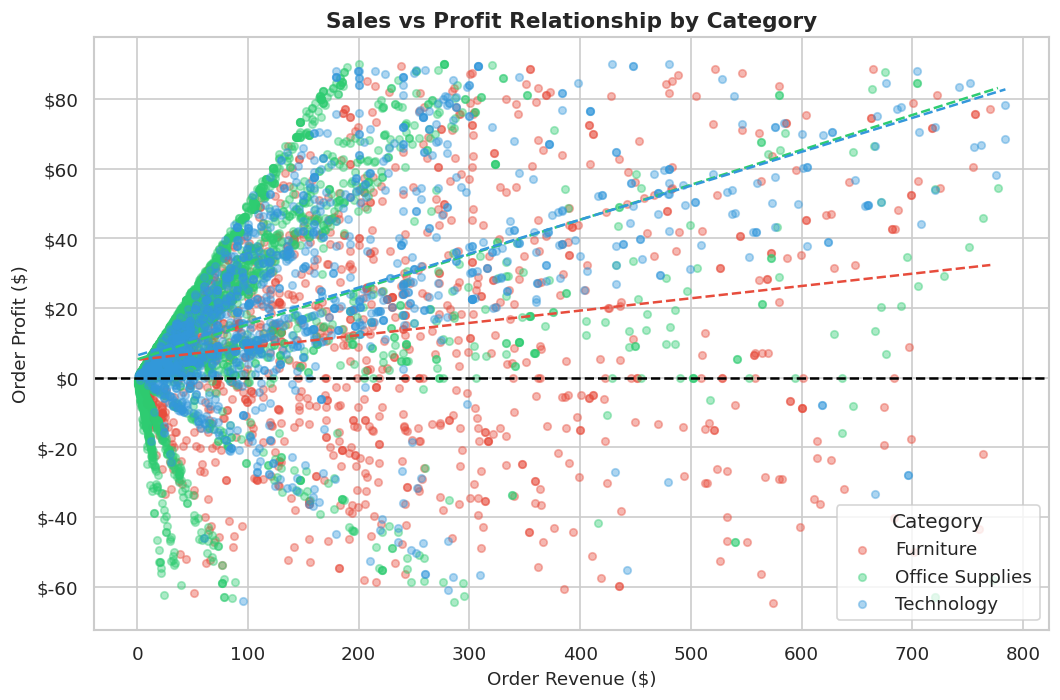

In [43]:
# --- Sales vs Profit Relationship ---
palette = {'Furniture': '#e74c3c','Technology': '#3498db','Office Supplies': '#2ecc71'}

fig, ax = plt.subplots(figsize=(9, 6))
for category, group in df.groupby('Category'):
    ax.scatter(group['Sales'], group['Profit'],
               alpha=0.4, s=20,
               color=palette.get(category, 'gray'),
               label=category)

    if len(group) > 1:
        z = np.polyfit(group['Sales'], group['Profit'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(group['Sales'].min(), group['Sales'].max(), 100)
        ax.plot(x_line, p(x_line),
                color=palette.get(category, 'gray'),
                linestyle='--', linewidth=1.5)

ax.axhline(0, color='black', linestyle='--')
ax.set_title('Sales vs Profit Relationship by Category')
ax.set_xlabel('Order Revenue ($)')
ax.set_ylabel('Order Profit ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(title='Category')

plt.tight_layout()
plt.show()

**Insight:**  
Furniture (red) has many high-revenue orders clustering near or below
zero — its trend line is almost flat, meaning selling more Furniture
does not reliably improve profit. Technology (blue) shows the steepest
positive slope — higher value orders generate more profit consistently.
Office Supplies (green) stays profitable across all order sizes despite
being low value per order. Revenue alone is a misleading metric here —
profit margin at sub-category level is the right KPI to track.

### Chart 6 — Customer Segment Profitability

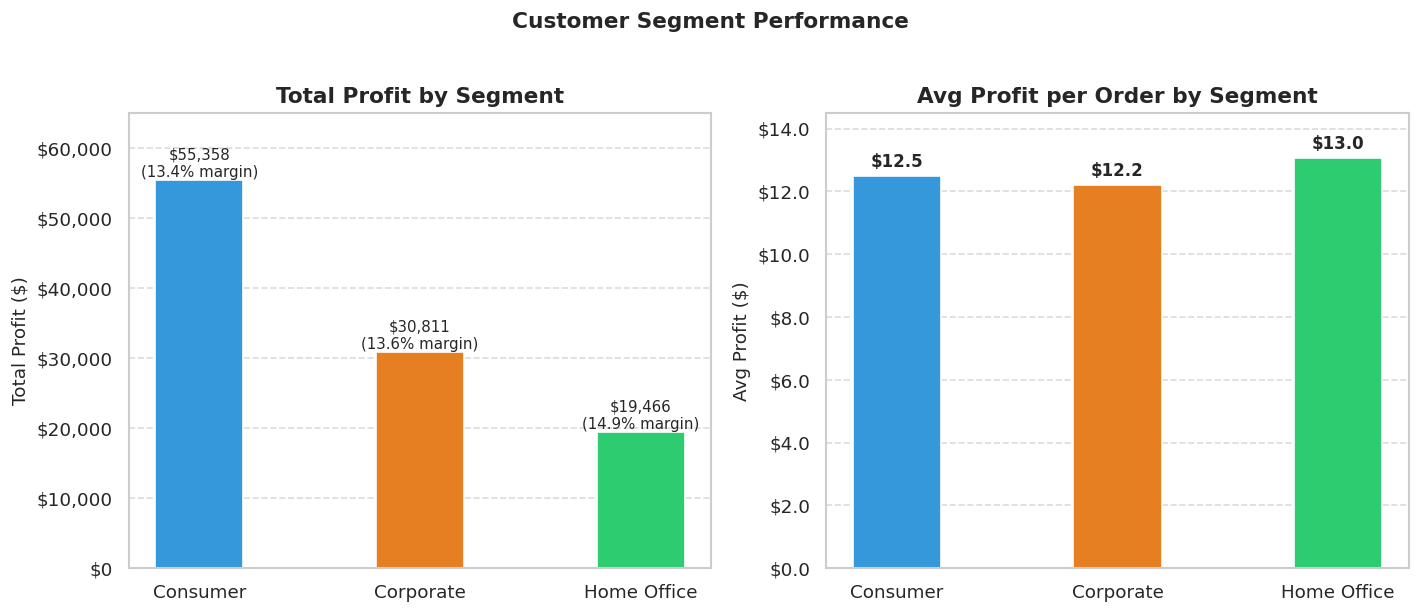

    Segment  Total_Orders  Total_Revenue  Total_Profit  Profit_Margin
   Consumer          4436      412764.93      55357.76           13.4
  Corporate          2524      226261.68      30810.68           13.6
Home Office          1492      130400.70      19465.86           14.9


In [44]:
seg_data = df.groupby('Segment').agg(
    Total_Revenue      = ('Sales',  'sum'),
    Total_Profit       = ('Profit', 'sum'),
    Avg_Profit_Per_Order= ('Profit','mean'),
    Total_Orders       = ('Sales',  'count')
).reset_index()
seg_data['Profit_Margin'] = round(seg_data['Total_Profit'] / seg_data['Total_Revenue'] * 100, 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left — Total Profit
colors = ['#3498db', '#e67e22', '#2ecc71']
axes[0].bar(seg_data['Segment'], seg_data['Total_Profit'], color=colors, edgecolor='white', width=0.4)
axes[0].set_title('Total Profit by Segment')
axes[0].set_ylabel('Total Profit ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

for i, (val, margin) in enumerate(zip(seg_data['Total_Profit'], seg_data['Profit_Margin'])):
    axes[0].text(i, val + 500, f'${val:,.0f}\n({margin}% margin)',
                 ha='center', fontsize=9)

# Right — Avg Profit per Order
axes[1].bar(seg_data['Segment'], seg_data['Avg_Profit_Per_Order'], color=colors, edgecolor='white', width=0.4)
axes[1].set_title('Avg Profit per Order by Segment')
axes[1].set_ylabel('Avg Profit ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.1f}'))

for i, val in enumerate(seg_data['Avg_Profit_Per_Order']):
    axes[1].text(i, val + 0.3, f'${val:.1f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Customer Segment Performance', fontsize=13, fontweight='bold', y=1.02)
for ax in axes:
    ax.yaxis.grid(True, linestyle='--', alpha=0.7) 
    ax.xaxis.grid(False)
axes[0].set_ylim(0,65000)
axes[1].set_ylim(0,14.5)
plt.tight_layout()
plt.show()

print(seg_data[['Segment','Total_Orders','Total_Revenue','Total_Profit','Profit_Margin']].to_string(index=False))

**Insight:**  
Consumer generates the most total profit (\\\$55,358) through volume —
52.5% of all orders at 13.4% margin. Home Office is the most efficient
segment with the highest margin (14.9%) and avg profit per order (13.0)
despite being only 17.7% of orders. Corporate sits in the middle on
both metrics. Two strategies can run in parallel — target Consumer
before September for peak season volume, while growing Home Office
year-round for margin improvement. These serve different goals and
are not competing priorities.

### Chart 7 — Monthly Sales Trend (Seasonality)

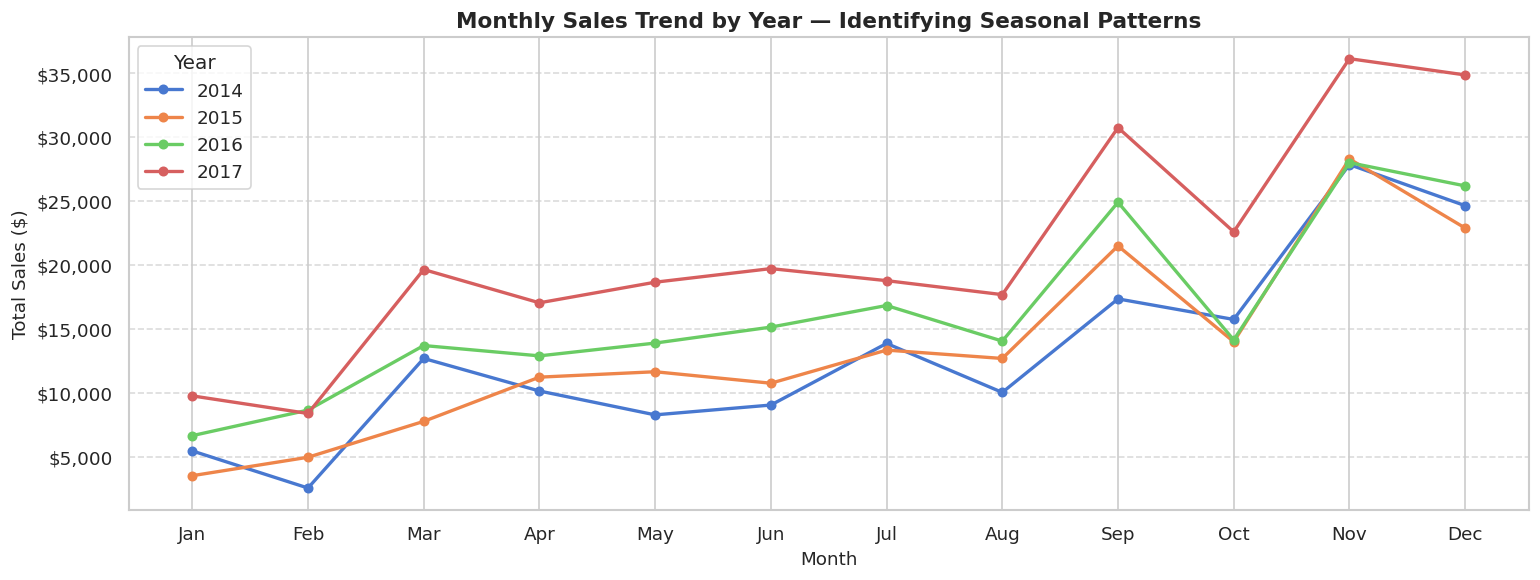

 Order_Year  Order_Month    Sales
       2014           11 27852.62
       2015           11 28298.13
       2016           11 28006.13
       2017           11 36136.56


In [45]:
monthly = df.groupby(['Order_Year', 'Order_Month'])['Sales'].sum().reset_index()
monthly['Date'] = pd.to_datetime({
    'year' : monthly['Order_Year'],
    'month': monthly['Order_Month'],
    'day'  : 1
})
fig, ax = plt.subplots(figsize=(13, 5))
for year, group in monthly.groupby('Order_Year'):
    ax.plot(group['Order_Month'], group['Sales'],
            marker='o', markersize=5, linewidth=2, label=str(year))

ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales ($)')
ax.set_title('Monthly Sales Trend by Year — Identifying Seasonal Patterns')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(title='Year')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
print(monthly.loc[monthly.groupby('Order_Year')['Sales'].idxmax(), 
                  ['Order_Year','Order_Month','Sales']].to_string(index=False))

**Insight:**  
November is the peak month every year without exception — \\\$27,852
in 2014 rising to \\\$36,136 in 2017. September is the second consistent
spike. October dips between both peaks every year. February is the
lowest point consistently. 2017 runs above all previous years
confirming year-on-year growth. Promotions must be ready in August
— waiting until October means the September spike has already passed.

### Chart 8 : Seasonal Sub-Category Spikes + Segment Buying Pattern (All Years)

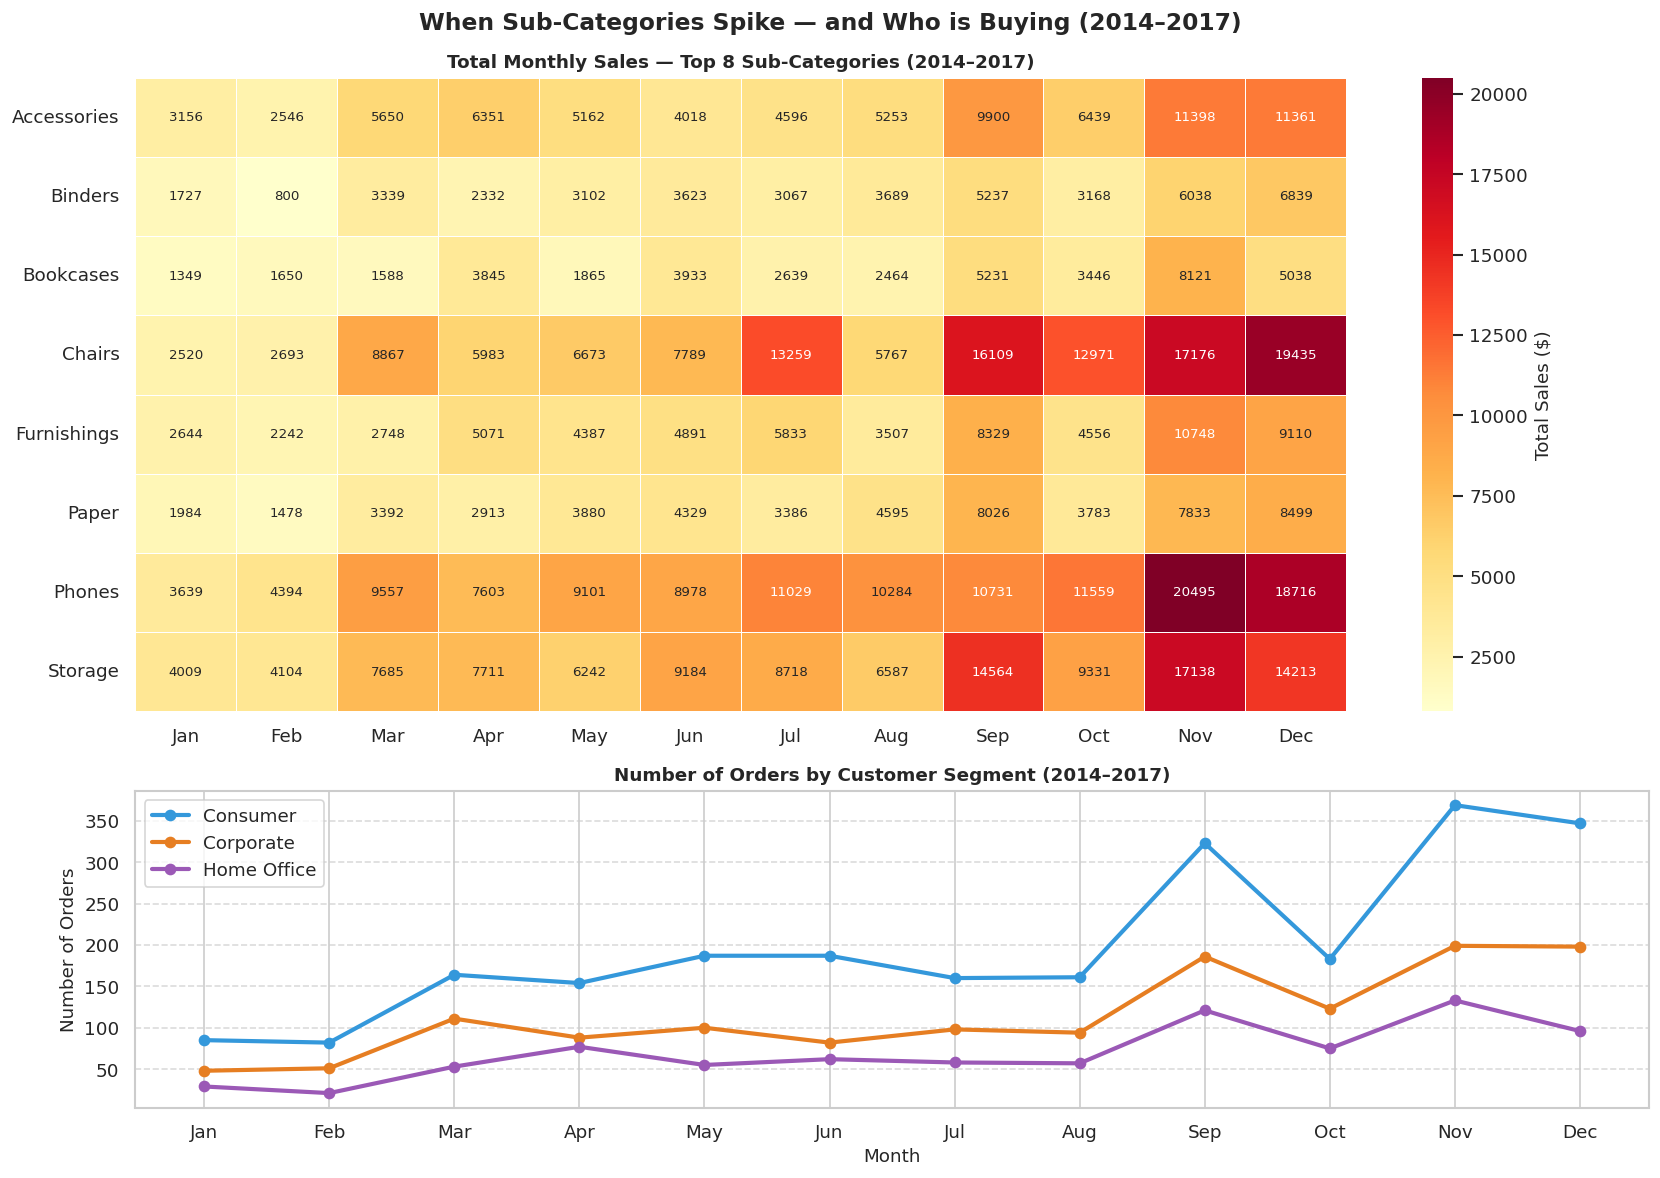

In [46]:
months_order = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

df['Month_Name'] = pd.Categorical(
    df['Order_Date'].dt.strftime('%b'), categories=months_order, ordered=True
)

# Top 8 sub-categories by total sales across all years
top8 = df.groupby('Sub_Category')['Sales'].sum() \
         .sort_values(ascending=False).head(8).index.tolist()

df_top8 = df[df['Sub_Category'].isin(top8)]

# Heatmap: TOTAL sales per sub-category per month
heat_data = df_top8.groupby(['Month_Name', 'Sub_Category'])['Sales'] \
                   .sum().unstack().reindex(months_order)

# Segment: ORDER COUNT per month
seg_orders = df.groupby(['Month_Name', 'Segment'])['Order_ID'] \
               .nunique().unstack().reindex(months_order)

# ── Plot ──
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10),
                                gridspec_kw={'height_ratios': [2, 1]})
fig.suptitle('When Sub-Categories Spike — and Who is Buying (2014–2017)',
             fontsize=14, fontweight='bold')

# --- Top: Heatmap ---
sns.heatmap(
    heat_data.T,
    ax=ax1,
    cmap='YlOrRd',
    linewidths=0.4,
    linecolor='white',
    fmt='.0f',
    annot=True,
    annot_kws={'size': 8},
    cbar_kws={'label': 'Total Sales ($)'}
)
ax1.set_title('Total Monthly Sales — Top 8 Sub-Categories (2014–2017)',
              fontsize=11, fontweight='bold')
ax1.set_xlabel('')
ax1.set_ylabel('')
ax1.tick_params(axis='x', rotation=0)
ax1.tick_params(axis='y', rotation=0)

# --- Bottom: Segment order count line chart ---
colors = {'Consumer'   : '#3498db',
          'Corporate'  : '#e67e22',
          'Home Office': '#9b59b6'}

for segment in seg_orders.columns:
    ax2.plot(months_order, seg_orders[segment],
             marker='o', linewidth=2.5, markersize=6,
             label=segment, color=colors[segment])

ax2.set_title('Number of Orders by Customer Segment (2014–2017)',
              fontsize=11, fontweight='bold')
ax2.set_ylabel('Number of Orders')
ax2.set_xlabel('Month')
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [47]:
# Verification — confirming Consumer is the primary buyer of top 4 sub-categories during peak season (Sep-Dec)
peak = df[df['Order_Month'].isin([9,10,11,12])]
top4 = ['Chairs','Phones','Storage','Accessories']

consumer_peak = peak[
    (peak['Segment'] == 'Consumer') &
    (peak['Sub_Category'].isin(top4))
].groupby('Sub_Category')['Sales'].sum().sort_values(ascending=False)

total_peak = peak[
    peak['Sub_Category'].isin(top4)
]['Sales'].groupby(peak['Sub_Category']).sum()

pct = (consumer_peak / total_peak * 100).round(1)

print('Consumer % of Sep-Dec sales — Top 4 Sub-Categories:')
print(pct.to_string())

Consumer % of Sep-Dec sales — Top 4 Sub-Categories:
Sub_Category
Accessories    54.1
Chairs         57.5
Phones         52.7
Storage        54.1


**Insight:**
Chairs and Phones show the darkest cells in Sep-Dec — the highest
revenue concentration of any sub-category across all 4 years. Phones
peak at 20,495 in November and Chairs at 19,435 in December. Consumer
segment is confirmed as the primary buyer — verified from data showing
Consumer accounts for 57.5% of Chairs, 54.1% of Storage, 54.1% of
Accessories and 52.7% of Phones sales during Sep-Dec specifically.
Stock these 4 sub-categories before September and run Consumer-targeted
promotions in August to capture demand before the spike hits.

### Chart 9 — Correlation Heatmap

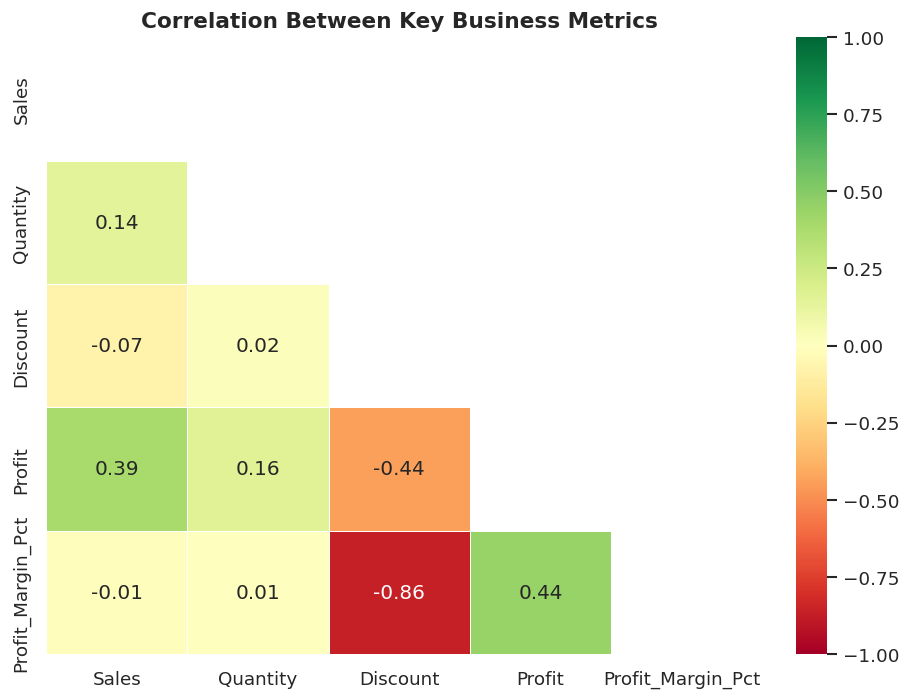

In [48]:
corr_cols = ['Sales', 'Quantity', 'Discount', 'Profit', 'Profit_Margin_Pct']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix,
            annot=True, fmt='.2f',
            cmap='RdYlGn',
            mask=mask,
            center=0, vmin=-1, vmax=1,
            linewidths=0.5,
            ax=ax)
ax.set_title('Correlation Between Key Business Metrics')
ax.xaxis.grid(False)
ax.yaxis.grid(False)
plt.tight_layout()
plt.show()

**Insight:**  
The strongest relationship in the dataset is Discount vs
Profit_Margin_Pct at -0.86 — a near-perfect negative correlation,
confirming what Chart 4 showed numerically. Every percentage point
of discount reliably reduces margin. Discount vs Profit also shows
-0.44, significant but weaker because absolute profit depends on
order size too. Sales and Profit correlate at only 0.39 — confirming
that higher revenue does not reliably mean higher profit, consistent
with what the scatter in Chart 5 showed.

In [49]:
print('=== PROJECT SUMMARY ===')
print(f'Total Revenue   : ${df["Sales"].sum():,.0f}')
print(f'Total Profit    : ${df["Profit"].sum():,.0f}')
print(f'Overall Margin  : {df["Profit"].sum()/df["Sales"].sum()*100:.1f}%')
print(f'Orders Analysed : {len(df):,}')
print(f'Date Range      : {df["Order_Date"].min().date()} to {df["Order_Date"].max().date()}')
print()
print('--- Key Numbers ---')
print(f'Profit destroyed by discounts > 20% : $-14,830 across 977 orders')
print(f'Central region margin gap vs average : 4.1 percentage points')
print(f'Sep-Dec revenue concentration        : {df[df["Order_Month"].isin([9,10,11,12])]["Sales"].sum()/df["Sales"].sum()*100:.1f}% of annual')
print(f'Home Office avg profit per order     : ${df[df["Segment"]=="Home Office"]["Profit"].mean():.2f}')

=== PROJECT SUMMARY ===
Total Revenue   : $769,427
Total Profit    : $105,634
Overall Margin  : 13.7%
Orders Analysed : 8,452
Date Range      : 2014-01-03 to 2017-12-30

--- Key Numbers ---
Profit destroyed by discounts > 20% : $-14,830 across 977 orders
Central region margin gap vs average : 4.1 percentage points
Sep-Dec revenue concentration        : 50.7% of annual
Home Office avg profit per order     : $13.05


## Step 6 — Summary of Business Findings

| # | Finding | Impact | Recommendation |
|---|---------|--------|----------------|
| 1 | 977 orders with discounts above 20% lost \\\$14,830 in profit on \\\$68,906 in revenue — 1 in 9 orders is actively losing money | High | Cap discounts at 20% company-wide. This is the single easiest profit fix available — no structural change needed |
| 2 | Tables is the only loss-making sub-category at \\\$-358 profit. Furniture's margin is 6.68% — less than half the business average of 13.73% | High | Check if Tables is being over-discounted. Chart 4 shows discounts above 20% destroy profit — Tables is the likely victim |
| 3 | Central region margin is 9.62% vs business average 13.73% — a 4.1 point gap worth \\\$6,666 in recoverable profit | High | Audit Central discount approvals. South runs at 15.22% on lower revenue — that discipline is replicable |
| 4 | Office Supplies leads margin at 19.69% through volume. Technology earns the highest avg profit per order at \\\$21.53 — nearly double Office Supplies | Medium | Track both metrics. Grow Technology order volume and protect Office Supplies margin — revenue figures alone are misleading |
| 5 | Sep-Dec generates 50.7% of annual revenue in 4 months. Consumer accounts for 54-57% of top sub-category sales in this window | Medium | Stock Chairs, Phones, Storage and Accessories before September. Run Consumer promotions in August — October is already too late |
| 6 | Home Office has the best margin (14.93%) and avg profit per order (13.05) but only 17.7% of orders | Low-Medium | Grow Home Office year-round through targeted campaigns. Consumer handles peak volume — Home Office improves margin efficiency |

In [26]:
df.to_csv('ecommerce_clean_powerbi.csv', index=False)
print(f'Exported {len(df):,} rows')
print(f'Columns : {df.columns.tolist()}')

Exported 8,452 rows
Columns : ['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode', 'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State', 'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category', 'Product_Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Order_Year', 'Order_Month', 'Order_Quarter', 'Month_Name', 'Profit_Margin_Pct', 'Discount_Band']
